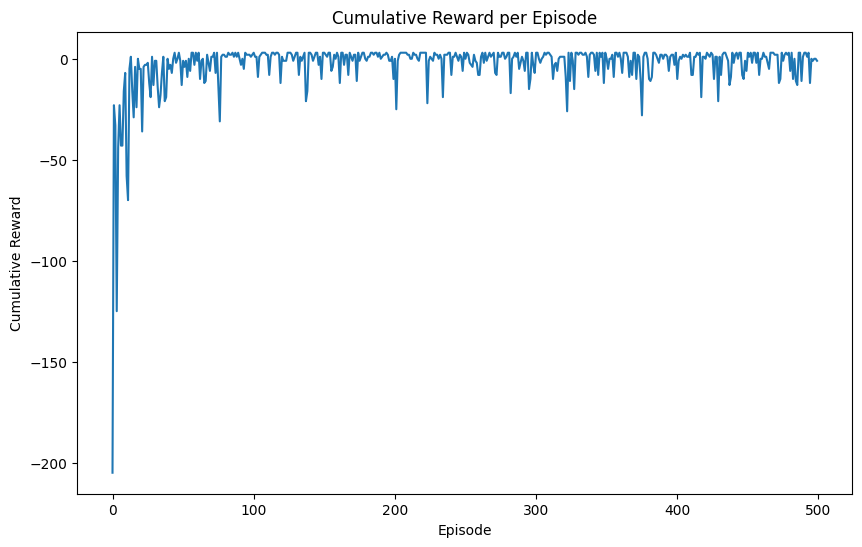

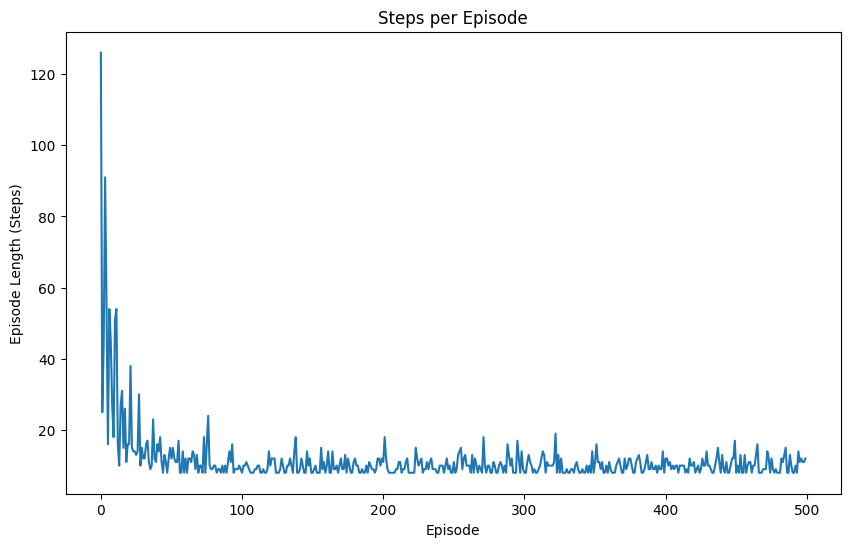

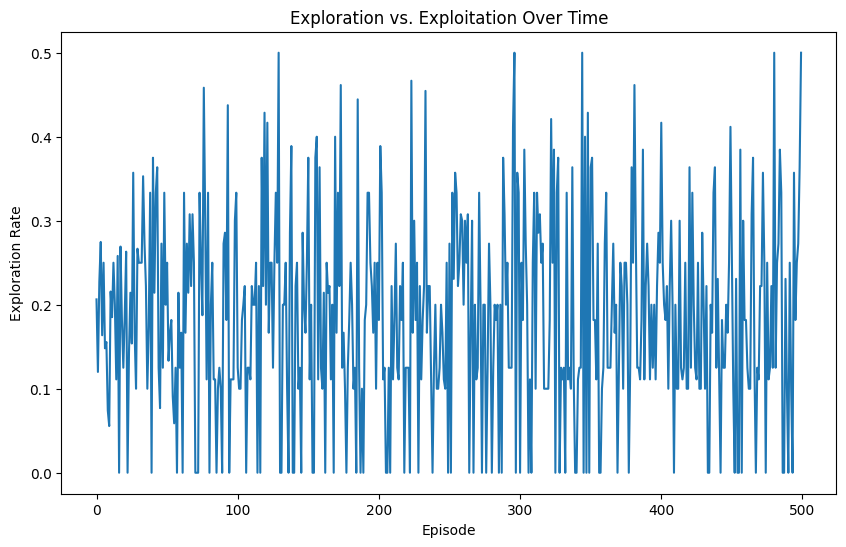

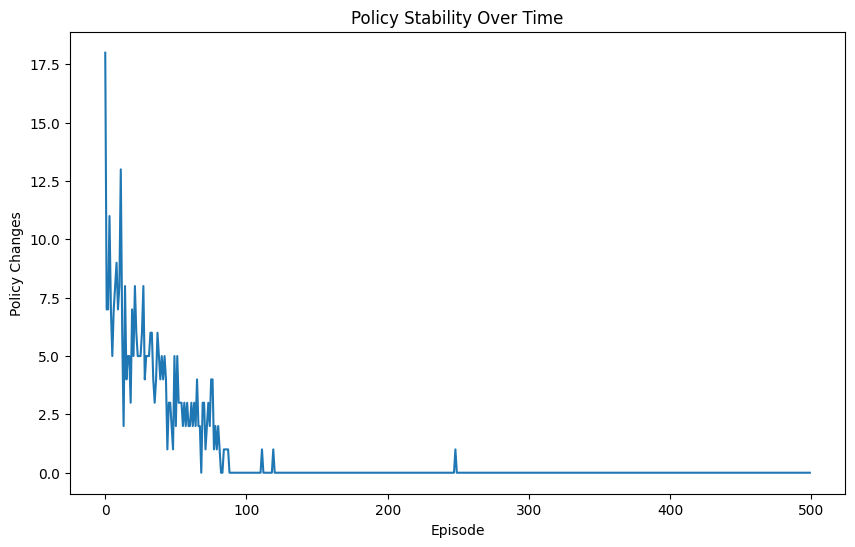

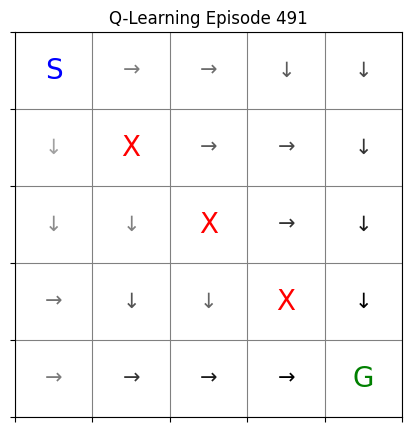

In [1]:
# Import required libraries
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# Set up environment parameters
grid_size = 5
start = (0, 0)
goal = (4, 4)
obstacles = [(1, 1), (2, 2), (3, 3)]  # Optional obstacles

# Actions (Up, Down, Left, Right)
actions = {
    0: (-1, 0),  # Up
    1: (1, 0),   # Down
    2: (0, -1),  # Left
    3: (0, 1)    # Right
}

# Initialize Q-table
q_table = np.zeros((grid_size, grid_size, len(actions)))

# Hyperparameters
alpha = 0.1    # Learning rate
gamma = 0.9    # Discount factor
epsilon = 0.2  # Exploration factor
episodes = 500  # Number of episodes for training

# Metrics storage
cumulative_rewards = []
episode_lengths = []
exploration_counts = []
policy_changes = []
frames = []  # Store frames for animation

# Reward function
def get_reward(state):
    if state == goal:
        return 10
    elif state in obstacles:
        return -10
    else:
        return -1

# Helper function to get new state
def get_next_state(state, action):
    next_state = (state[0] + action[0], state[1] + action[1])
    if 0 <= next_state[0] < grid_size and 0 <= next_state[1] < grid_size:
        return next_state
    else:
        return state  # Stay in the same place if move is out of bounds

# Training function for Q-Learning
def train_agent():
    for episode in range(episodes):
        state = start
        episode_reward = 0  # Track cumulative reward
        steps = 0           # Track episode length
        explore_count = 0
        exploit_count = 0
        policy_change_count = 0
        previous_policy = np.copy(q_table)  # Snapshot of policy at episode start

        while state != goal:
            # Epsilon-greedy action selection
            if random.uniform(0, 1) < epsilon:
                action_idx = random.choice(list(actions.keys()))
                explore_count += 1
            else:
                action_idx = np.argmax(q_table[state[0], state[1]])
                exploit_count += 1

            # Take action and observe reward
            action = actions[action_idx]
            next_state = get_next_state(state, action)
            reward = get_reward(next_state)

            # Update Q-value
            old_value = q_table[state[0], state[1], action_idx]
            next_max = np.max(q_table[next_state[0], next_state[1]])
            q_table[state[0], state[1], action_idx] = old_value + alpha * (reward + gamma * next_max - old_value)

            # Move to next state and accumulate metrics
            episode_reward += reward
            steps += 1
            state = next_state

        # Record policy changes
        for x in range(grid_size):
            for y in range(grid_size):
                if np.argmax(previous_policy[x, y]) != np.argmax(q_table[x, y]):
                    policy_change_count += 1

        # Store metrics after each episode
        cumulative_rewards.append(episode_reward)
        episode_lengths.append(steps)
        exploration_counts.append((explore_count, exploit_count))
        policy_changes.append(policy_change_count)

        # Capture frames every 10 episodes for the animation
        if episode % 10 == 0:
            frames.append((np.copy(q_table), episode + 1))

# Plotting function for all metrics
def plot_metrics():
    # Cumulative Rewards
    plt.figure(figsize=(10, 6))
    plt.plot(cumulative_rewards)
    plt.xlabel('Episode')
    plt.ylabel('Cumulative Reward')
    plt.title('Cumulative Reward per Episode')
    plt.show()

    # Episode Length
    plt.figure(figsize=(10, 6))
    plt.plot(episode_lengths)
    plt.xlabel('Episode')
    plt.ylabel('Episode Length (Steps)')
    plt.title('Steps per Episode')
    plt.show()

    # Exploration vs Exploitation Ratio
    explore_ratios = [explore / (explore + exploit) for explore, exploit in exploration_counts]
    plt.figure(figsize=(10, 6))
    plt.plot(explore_ratios, label="Exploration Rate")
    plt.xlabel('Episode')
    plt.ylabel('Exploration Rate')
    plt.title('Exploration vs. Exploitation Over Time')
    plt.show()

    # Policy Stability
    plt.figure(figsize=(10, 6))
    plt.plot(policy_changes)
    plt.xlabel('Episode')
    plt.ylabel('Policy Changes')
    plt.title('Policy Stability Over Time')
    plt.show()

# Visualization of the learning process
def animate_learning():
    fig, ax = plt.subplots(figsize=(5, 5))

    def animate(i):
        ax.clear()
        q_table, episode = frames[i]
        ax.set_title(f"Q-Learning Episode {episode}")

        # Display the Q-values as arrows with color intensity
        for x in range(grid_size):
            for y in range(grid_size):
                max_action = np.argmax(q_table[x, y])
                max_q_value = np.max(q_table[x, y])
                intensity = (max_q_value - np.min(q_table)) / (np.max(q_table) - np.min(q_table) + 1e-6)
                color = (0, 0, 0, intensity)  # Darker color for higher Q-values

                if (x, y) == goal:
                    ax.text(y, x, 'G', ha='center', va='center', color='green', fontsize=20)
                elif (x, y) in obstacles:
                    ax.text(y, x, 'X', ha='center', va='center', color='red', fontsize=20)
                elif (x, y) == start:
                    ax.text(y, x, 'S', ha='center', va='center', color='blue', fontsize=20)
                else:
                    arrow = {0: '↑', 1: '↓', 2: '←', 3: '→'}[max_action]
                    ax.text(y, x, arrow, ha='center', va='center', color=color, fontsize=15)

        ax.set_xticks(np.arange(-0.5, grid_size, 1))
        ax.set_yticks(np.arange(-0.5, grid_size, 1))
        ax.grid(color='gray')
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        plt.gca().invert_yaxis()

    # Create the animation and assign it to a variable to prevent garbage collection
    anim = animation.FuncAnimation(fig, animate, frames=len(frames), interval=100)

    # Return the animation for inline display in Jupyter
    return HTML(anim.to_jshtml())

# Run the training, plot metrics, and show animation
train_agent()
plot_metrics()
animate_learning()  # Ensure the return value is displayed


In [3]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import defaultdict
from IPython.display import HTML
from matplotlib import animation

def run_experiment(alpha, gamma, epsilon, episodes, obstacles=None, goal=None,
                  step_penalty=-1, obstacle_penalty=-10, grid_size=5, start=(0, 0)):
    if goal is None:
        goal = (4, 4)
    if obstacles is None:
        obstacles = [(1, 1), (2, 2), (3, 3)]

    actions = {
        0: (-1, 0),  # Up
        1: (1, 0),   # Down
        2: (0, -1),  # Left
        3: (0, 1)    # Right
    }

    q_table = np.zeros((grid_size, grid_size, len(actions)))
    metrics = {
        'cumulative_rewards': [],
        'episode_lengths': [],
        'exploration_rates': [],
        'policy_changes': [],
        'final_path': None
    }

    def get_reward(state):
        if state == goal:
            return 10
        elif state in obstacles:
            return obstacle_penalty
        else:
            return step_penalty

    def get_next_state(state, action):
        next_state = (state[0] + action[0], state[1] + action[1])
        if 0 <= next_state[0] < grid_size and 0 <= next_state[1] < grid_size:
            return next_state
        return state

    for episode in range(episodes):
        state = start
        episode_reward = 0
        steps = 0
        explore_count = 0
        previous_policy = np.copy(q_table)
        path = [state]

        while state != goal and steps < 100:
            if random.uniform(0, 1) < epsilon:
                action_idx = random.choice(list(actions.keys()))
                explore_count += 1
            else:
                action_idx = np.argmax(q_table[state[0], state[1]])

            action = actions[action_idx]
            next_state = get_next_state(state, action)
            reward = get_reward(next_state)

            old_value = q_table[state[0], state[1], action_idx]
            next_max = np.max(q_table[next_state[0], next_state[1]])
            q_table[state[0], state[1], action_idx] = old_value + alpha * (reward + gamma * next_max - old_value)

            episode_reward += reward
            steps += 1
            state = next_state
            path.append(state)

        policy_changes = np.sum(np.argmax(previous_policy, axis=2) != np.argmax(q_table, axis=2))

        metrics['cumulative_rewards'].append(episode_reward)
        metrics['episode_lengths'].append(steps)
        metrics['exploration_rates'].append(explore_count / steps)
        metrics['policy_changes'].append(policy_changes)

        if episode == episodes - 1:
            metrics['final_path'] = path

    return metrics, q_table

def plot_comparison(results, metric, title):
    plt.figure(figsize=(12, 6))
    for label, metrics in results.items():
        plt.plot(metrics[metric], label=label)
    plt.xlabel('Episode')
    plt.ylabel(metric.replace('_', ' ').title())
    plt.title(title)
    plt.legend()
    plt.show()

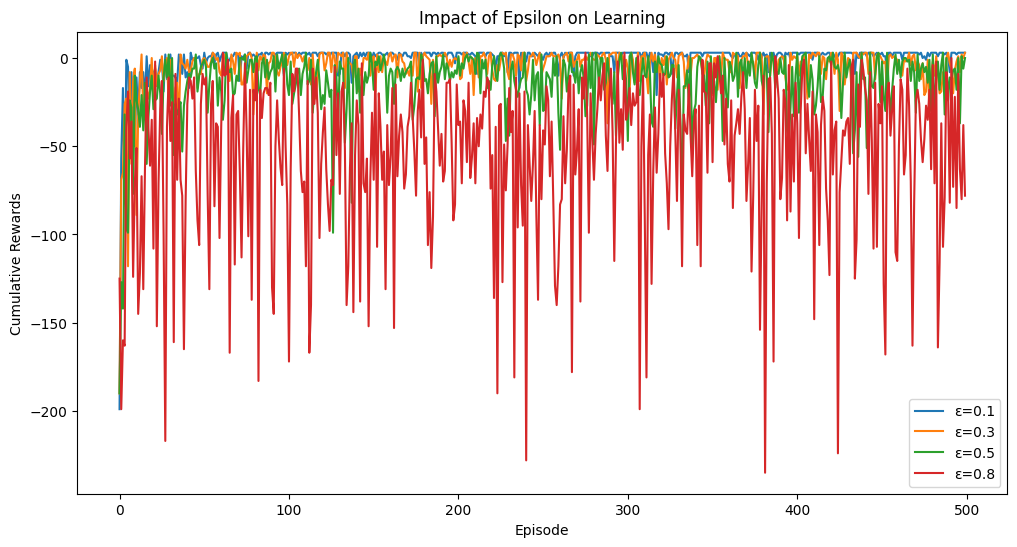

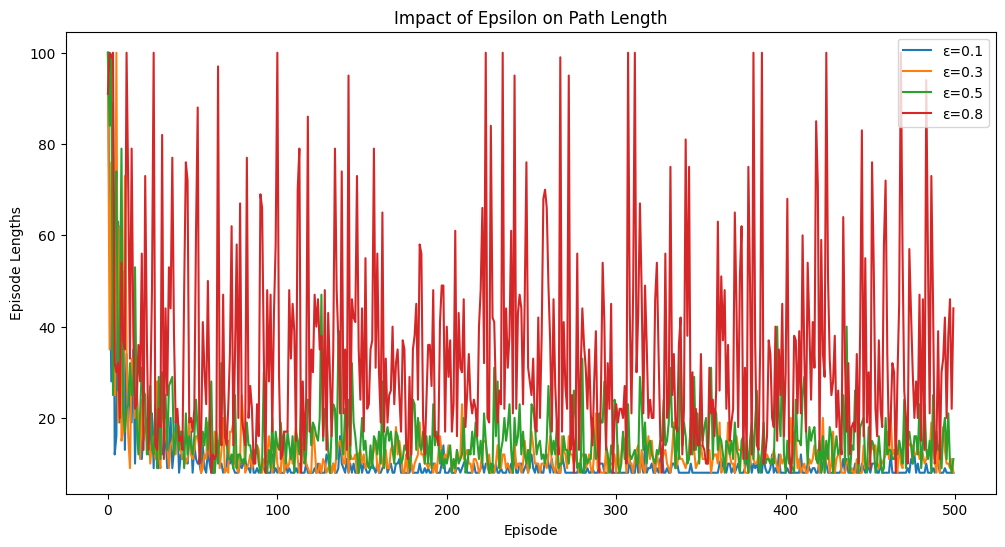

In [4]:
# Experiment 1: Varying Epsilon
epsilon_experiments = [
    {'alpha': 0.1, 'gamma': 0.9, 'epsilon': eps}
    for eps in [0.1, 0.3, 0.5, 0.8]
]

epsilon_results = {}
for params in epsilon_experiments:
    metrics, _ = run_experiment(**params, episodes=500)
    epsilon_results[f"ε={params['epsilon']}"] = metrics

plot_comparison(epsilon_results, 'cumulative_rewards', 'Impact of Epsilon on Learning')
plot_comparison(epsilon_results, 'episode_lengths', 'Impact of Epsilon on Path Length')

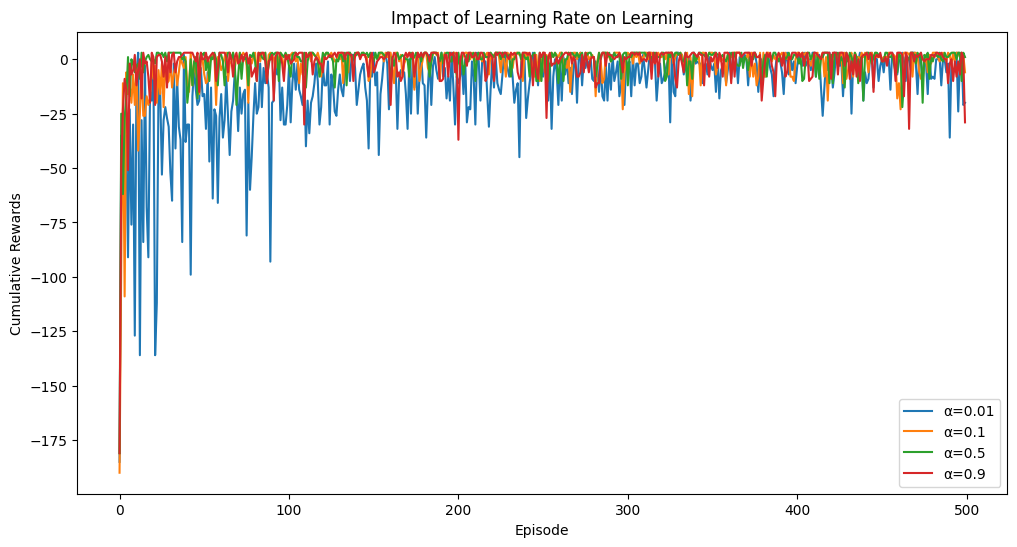

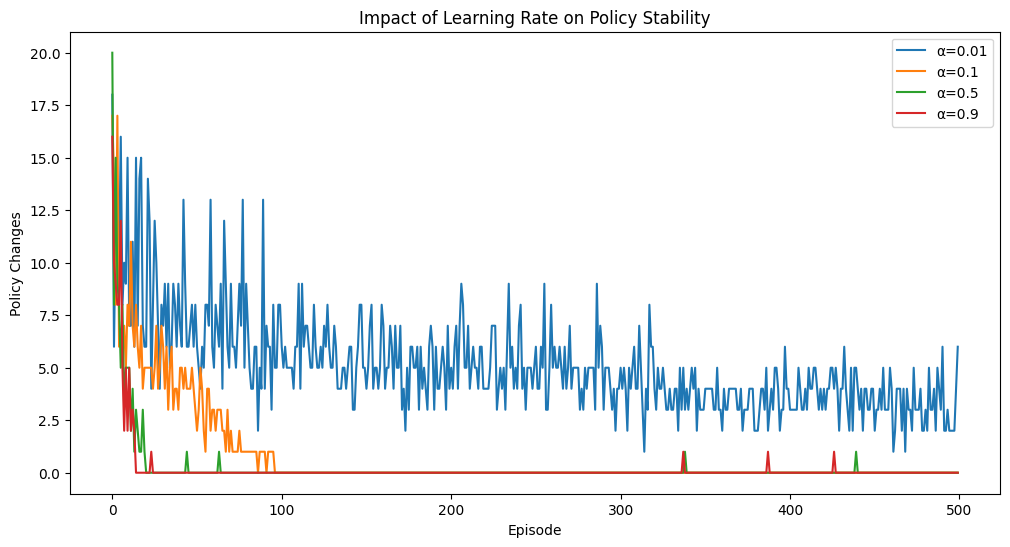

In [5]:
# Experiment 2: Varying Alpha
alpha_experiments = [
    {'alpha': alpha, 'gamma': 0.9, 'epsilon': 0.2}
    for alpha in [0.01, 0.1, 0.5, 0.9]
]

alpha_results = {}
for params in alpha_experiments:
    metrics, _ = run_experiment(**params, episodes=500)
    alpha_results[f"α={params['alpha']}"] = metrics

plot_comparison(alpha_results, 'cumulative_rewards', 'Impact of Learning Rate on Learning')
plot_comparison(alpha_results, 'policy_changes', 'Impact of Learning Rate on Policy Stability')

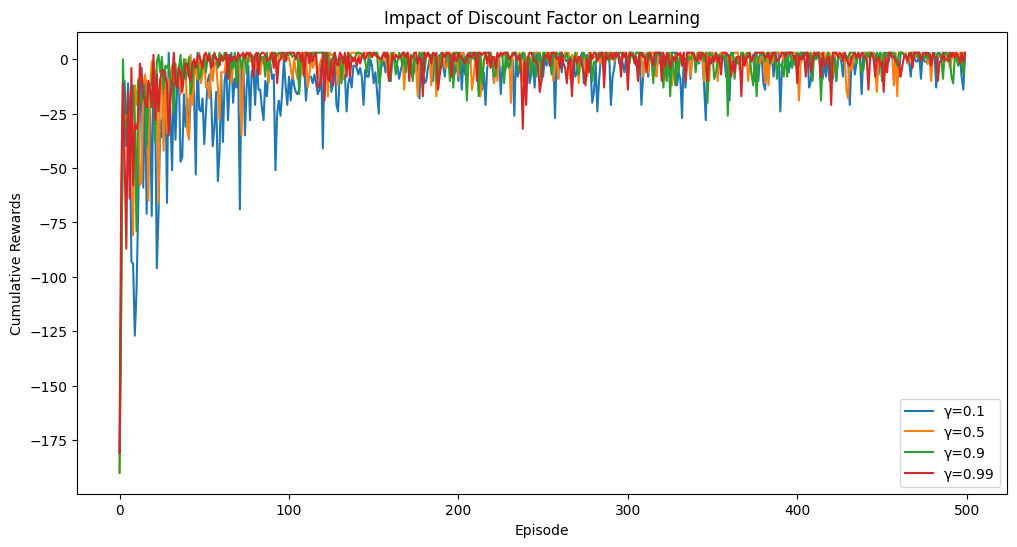

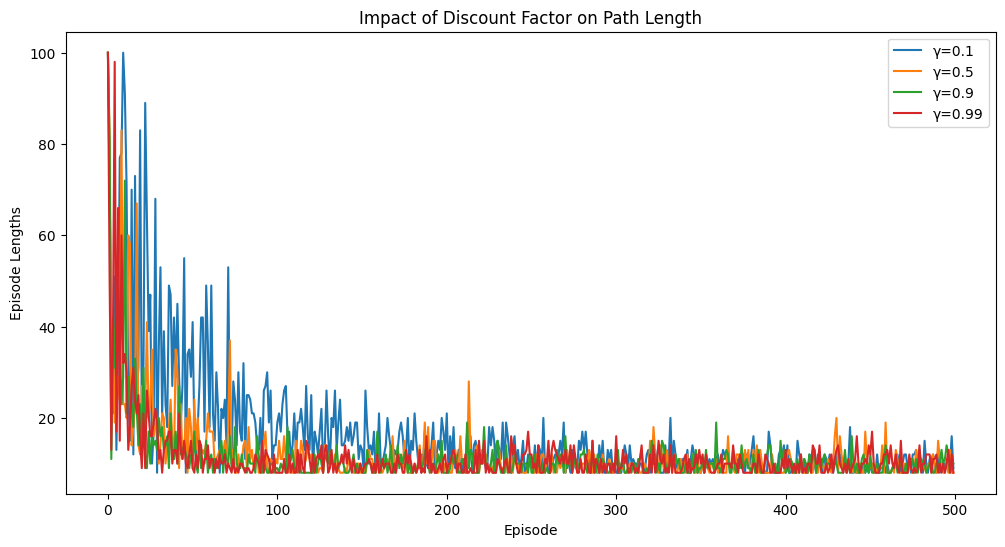

In [6]:
# Experiment 3: Varying Gamma
gamma_experiments = [
    {'alpha': 0.1, 'gamma': gamma, 'epsilon': 0.2}
    for gamma in [0.1, 0.5, 0.9, 0.99]
]

gamma_results = {}
for params in gamma_experiments:
    metrics, _ = run_experiment(**params, episodes=500)
    gamma_results[f"γ={params['gamma']}"] = metrics

plot_comparison(gamma_results, 'cumulative_rewards', 'Impact of Discount Factor on Learning')
plot_comparison(gamma_results, 'episode_lengths', 'Impact of Discount Factor on Path Length')

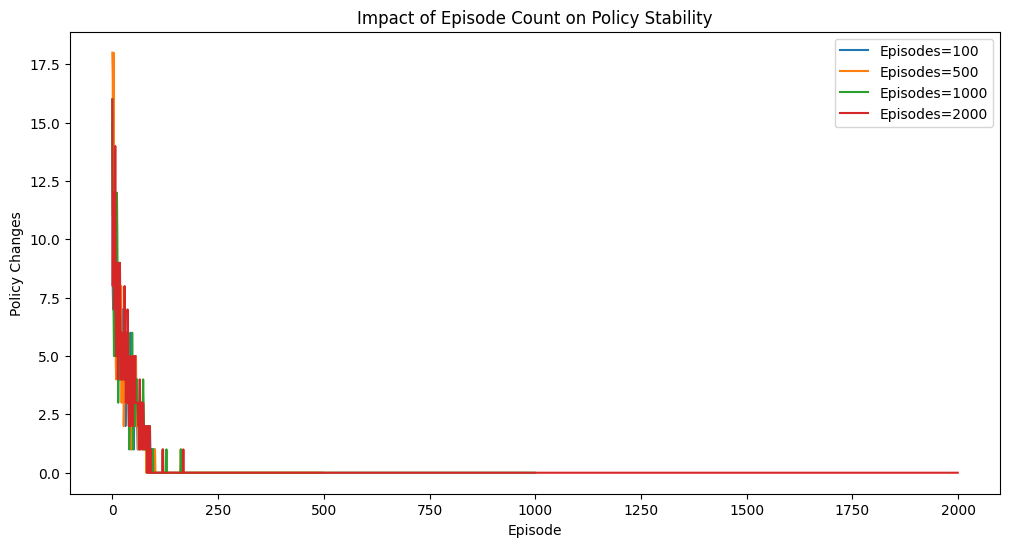

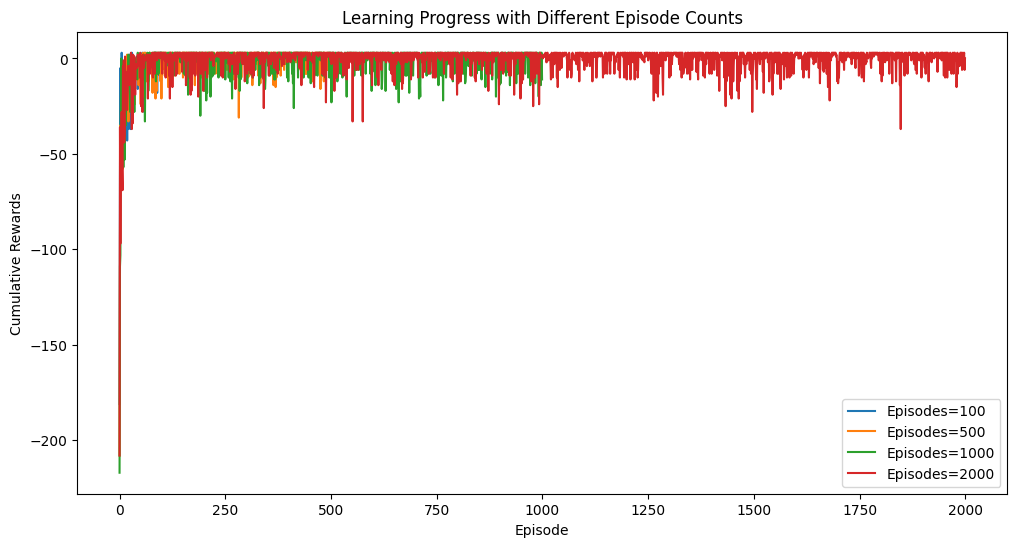

In [7]:
# Experiment 4: Varying Episode Count
episode_experiments = [100, 500, 1000, 2000]
episode_results = {}

for ep_count in episode_experiments:
    metrics, _ = run_experiment(alpha=0.1, gamma=0.9, epsilon=0.2, episodes=ep_count)
    episode_results[f"Episodes={ep_count}"] = metrics

plot_comparison(episode_results, 'policy_changes', 'Impact of Episode Count on Policy Stability')
plot_comparison(episode_results, 'cumulative_rewards', 'Learning Progress with Different Episode Counts')

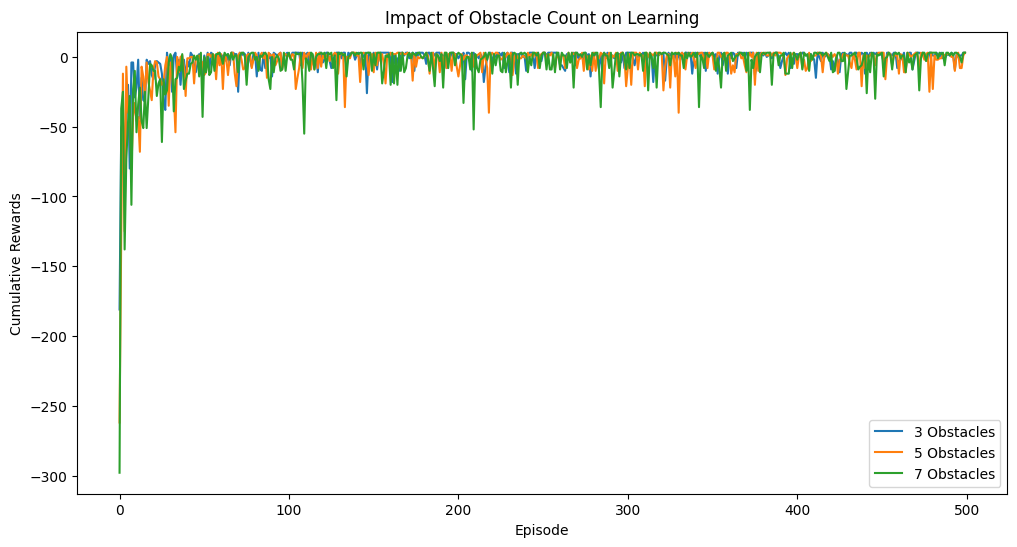

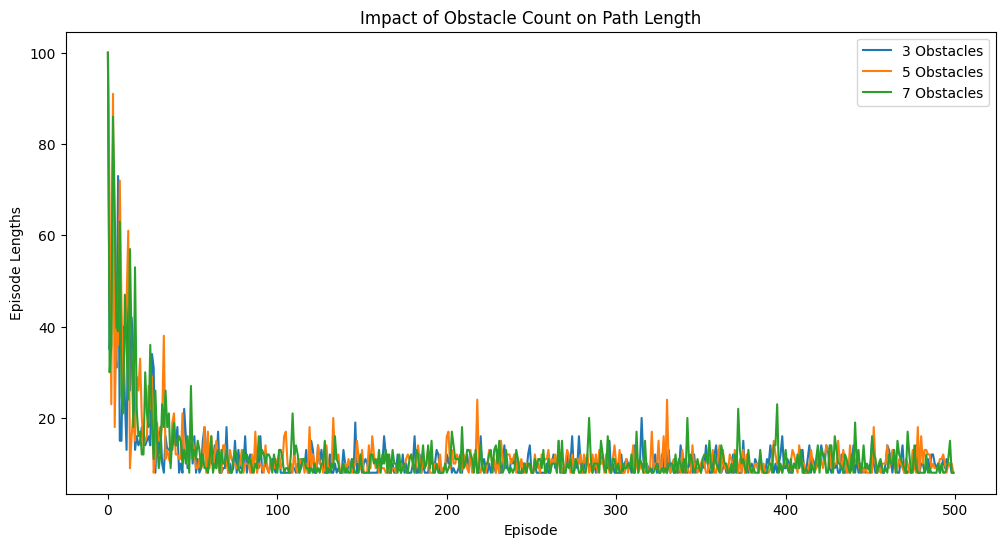

In [8]:
# Experiment 5: Varying Obstacle Count
base_obstacles = [(1, 1), (2, 2), (3, 3)]
more_obstacles = base_obstacles + [(1, 3), (3, 1)]
most_obstacles = more_obstacles + [(2, 3), (3, 2)]

obstacle_experiments = {
    '3 Obstacles': base_obstacles,
    '5 Obstacles': more_obstacles,
    '7 Obstacles': most_obstacles
}

obstacle_results = {}
for label, obs in obstacle_experiments.items():
    metrics, _ = run_experiment(alpha=0.1, gamma=0.9, epsilon=0.2, episodes=500, obstacles=obs)
    obstacle_results[label] = metrics

plot_comparison(obstacle_results, 'cumulative_rewards', 'Impact of Obstacle Count on Learning')
plot_comparison(obstacle_results, 'episode_lengths', 'Impact of Obstacle Count on Path Length')

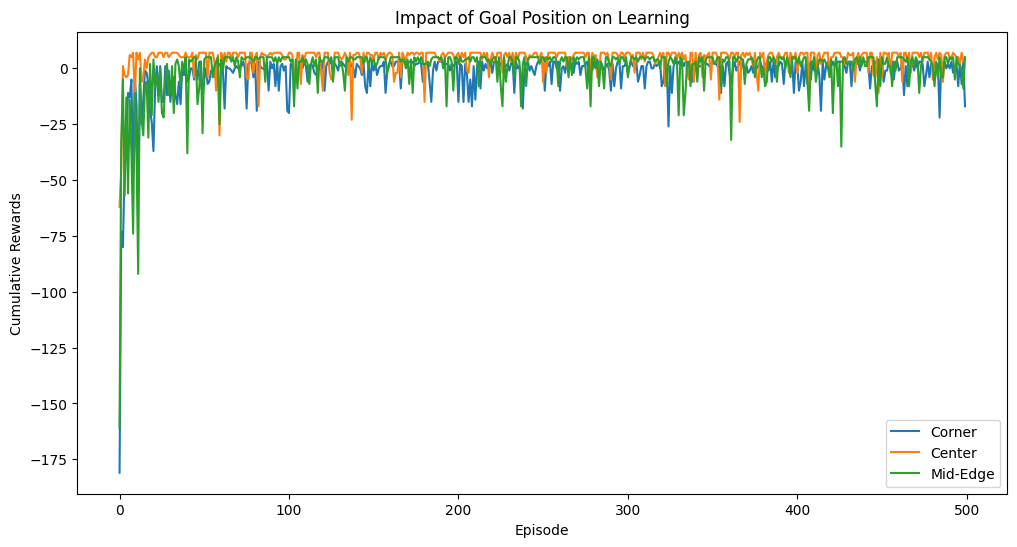

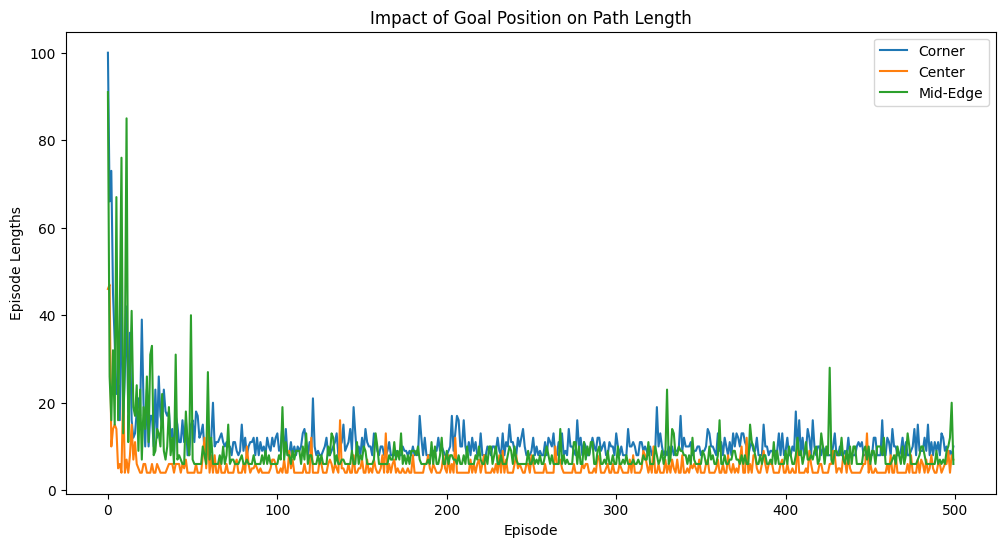

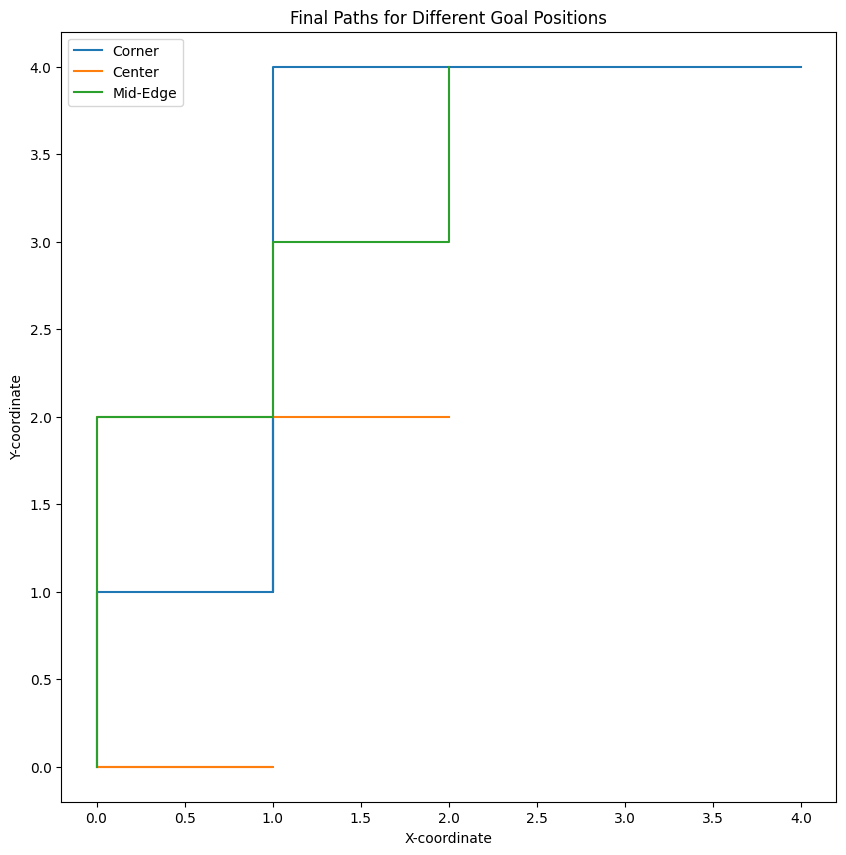

In [9]:
# Experiment 6: Different Goal Positions
goal_positions = {
    'Corner': (4, 4),
    'Center': (2, 2),
    'Mid-Edge': (2, 4)
}

goal_results = {}
for label, goal_pos in goal_positions.items():
    metrics, _ = run_experiment(alpha=0.1, gamma=0.9, epsilon=0.2, episodes=500, goal=goal_pos)
    goal_results[label] = metrics

plot_comparison(goal_results, 'cumulative_rewards', 'Impact of Goal Position on Learning')
plot_comparison(goal_results, 'episode_lengths', 'Impact of Goal Position on Path Length')

# Visualize final paths for different goal positions
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title('Final Paths for Different Goal Positions')
ax.set_xlabel('X-coordinate')
ax.set_ylabel('Y-coordinate')

for label, metrics in goal_results.items():
    path = metrics['final_path']
    x_coords, y_coords = zip(*path)
    ax.plot(x_coords, y_coords, label=label)

ax.legend()
plt.show()

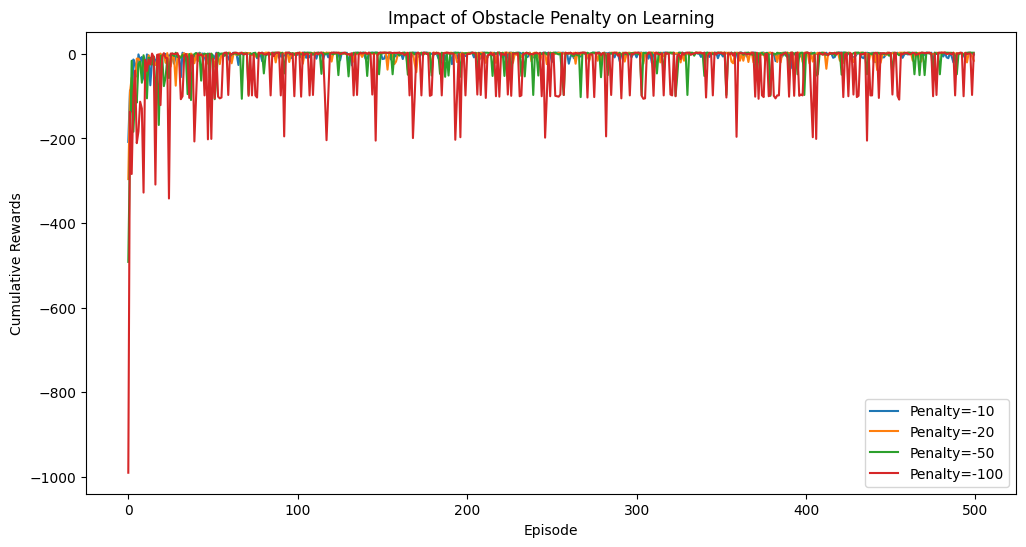

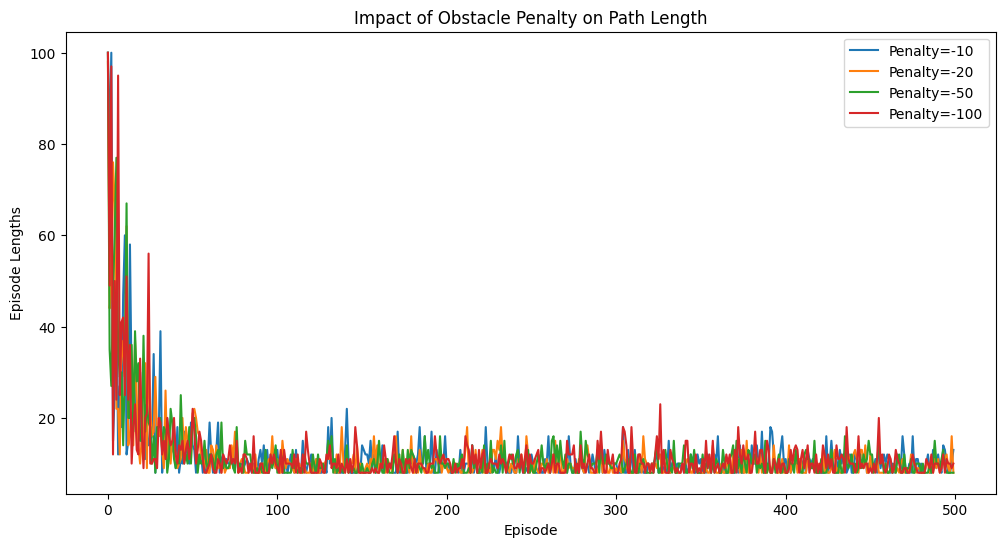

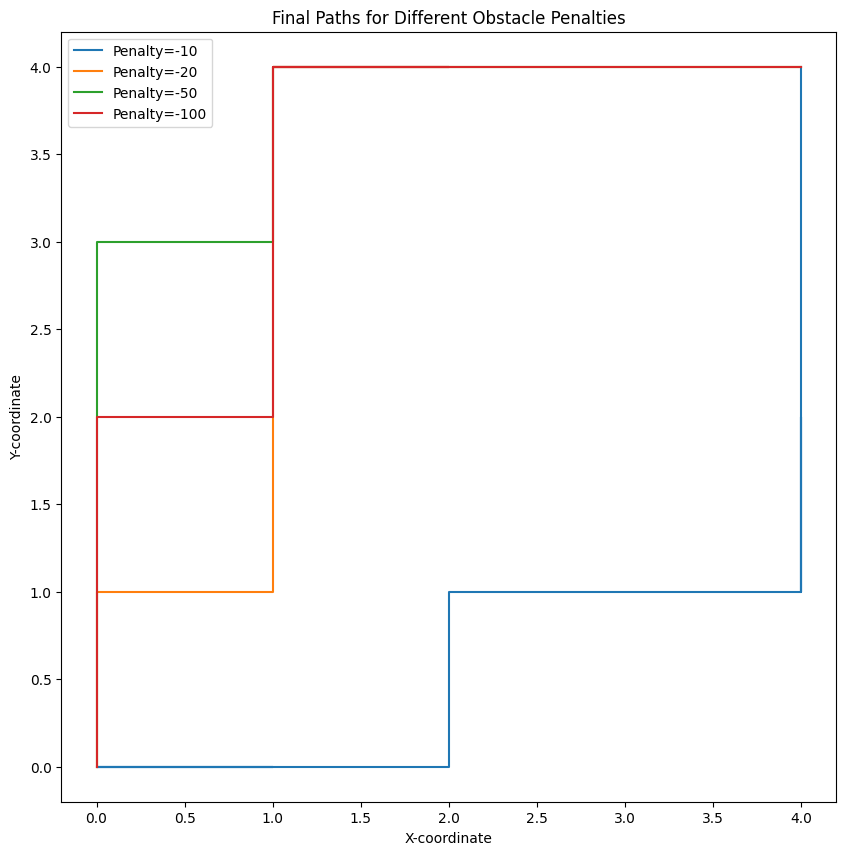

In [10]:
# Experiment 7: Varying Penalty Values
penalty_experiments = [
    {'alpha': 0.1, 'gamma': 0.9, 'epsilon': 0.2, 'step_penalty': -1, 'obstacle_penalty': -10},
    {'alpha': 0.1, 'gamma': 0.9, 'epsilon': 0.2, 'step_penalty': -1, 'obstacle_penalty': -20},
    {'alpha': 0.1, 'gamma': 0.9, 'epsilon': 0.2, 'step_penalty': -1, 'obstacle_penalty': -50},
    {'alpha': 0.1, 'gamma': 0.9, 'epsilon': 0.2, 'step_penalty': -1, 'obstacle_penalty': -100}
]

penalty_results = {}
for params in penalty_experiments:
    metrics, _ = run_experiment(**params, episodes=500)
    penalty_results[f"Penalty={params['obstacle_penalty']}"] = metrics

plot_comparison(penalty_results, 'cumulative_rewards', 'Impact of Obstacle Penalty on Learning')
plot_comparison(penalty_results, 'episode_lengths', 'Impact of Obstacle Penalty on Path Length')

# Visualize final paths for different obstacle penalties
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title('Final Paths for Different Obstacle Penalties')
ax.set_xlabel('X-coordinate')
ax.set_ylabel('Y-coordinate')

for label, metrics in penalty_results.items():
    path = metrics['final_path']
    x_coords, y_coords = zip(*path)
    ax.plot(x_coords, y_coords, label=label)

ax.legend()
plt.show()

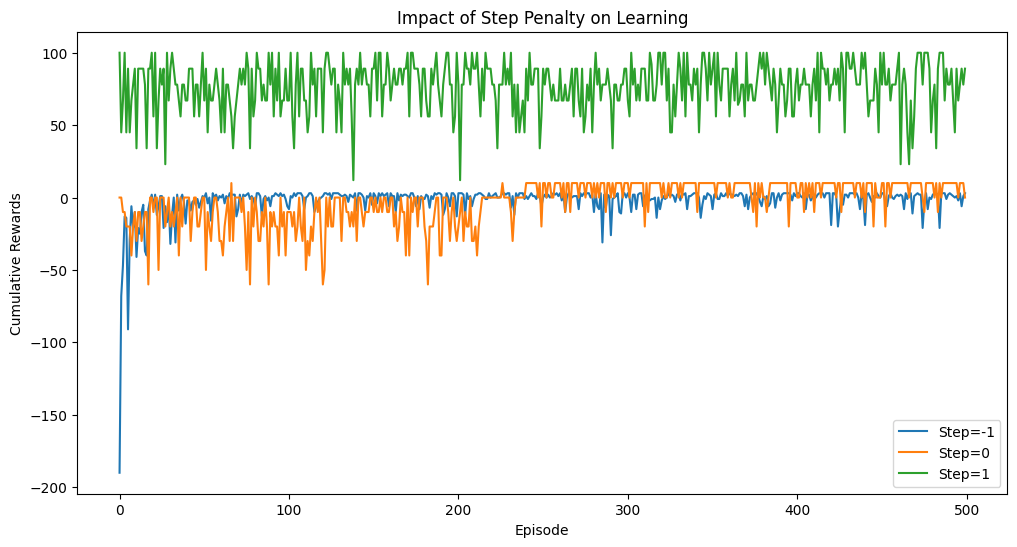

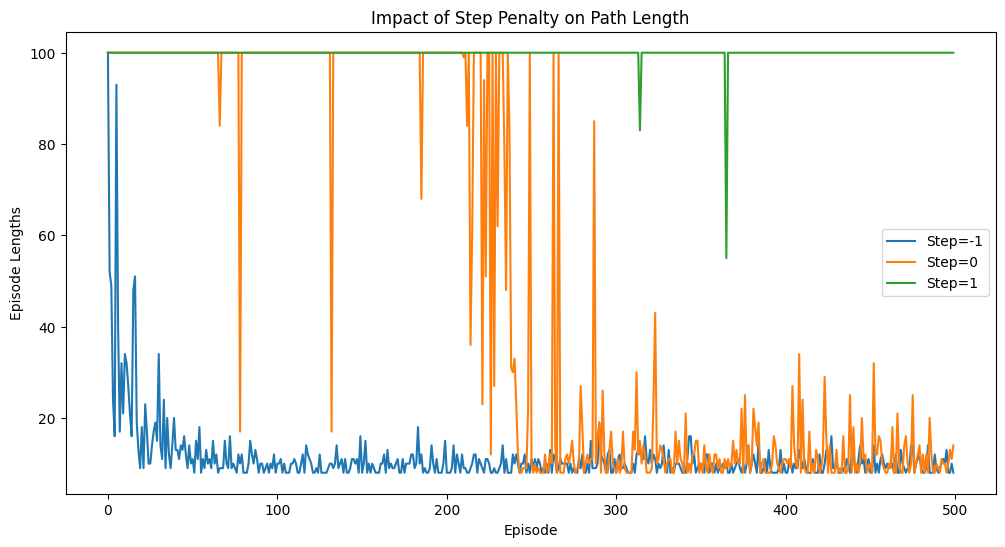

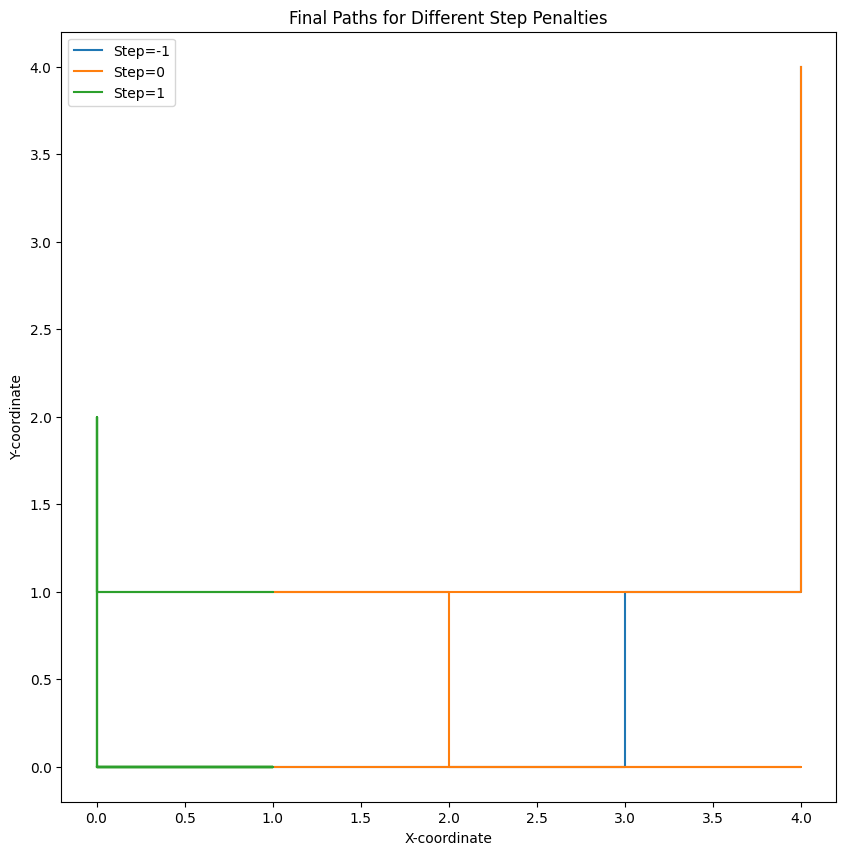

In [11]:
# Experiment 8: Varying Step Penalties
step_experiments = [
    {'alpha': 0.1, 'gamma': 0.9, 'epsilon': 0.2, 'step_penalty': -1, 'obstacle_penalty': -10},
    {'alpha': 0.1, 'gamma': 0.9, 'epsilon': 0.2, 'step_penalty': 0, 'obstacle_penalty': -10},
    {'alpha': 0.1, 'gamma': 0.9, 'epsilon': 0.2, 'step_penalty': 1, 'obstacle_penalty': -10}
]

step_results = {}
for params in step_experiments:
    metrics, _ = run_experiment(**params, episodes=500)
    step_results[f"Step={params['step_penalty']}"] = metrics

plot_comparison(step_results, 'cumulative_rewards', 'Impact of Step Penalty on Learning')
plot_comparison(step_results, 'episode_lengths', 'Impact of Step Penalty on Path Length')

# Visualize final paths for different step penalties
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title('Final Paths for Different Step Penalties')
ax.set_xlabel('X-coordinate')
ax.set_ylabel('Y-coordinate')

for label, metrics in step_results.items():
    path = metrics['final_path']
    x_coords, y_coords = zip(*path)
    ax.plot(x_coords, y_coords, label=label)

ax.legend()
plt.show()

#Observations:

Let me break this down and rephrase it in simpler, more natural language.

### Experiment 1
When we set epsilon high, our agent tries lots of random moves to learn about its environment. With low epsilon, it sticks to what it knows works - this can help it learn quickly at first, but it might miss better solutions by not trying new things.

### Experiment 2
With a low learning rate, the agent is cautious and changes its behavior slowly. This makes learning take longer but is more stable. A high learning rate means quick learning but can make the agent's behavior jumpy and unreliable.

### Experiment 3
When gamma is low, the agent only cares about quick wins - like taking the shortest path right now. High gamma makes it think ahead more, like a chess player planning several moves in advance.

### Experiment 4
More practice (episodes) usually means better performance - just like with humans. However, there's a point where extra practice doesn't help much anymore, like when you've already mastered a skill.

### Experiment 5
Adding more obstacles makes the task harder, naturally. The agent needs more time to figure out good paths when there are more things in the way.

### Experiment 6
When we move the goal, it's like changing the rules mid-game. The agent needs time to forget its old habits and learn new ones. The bigger the change, the longer this takes.

### Experiment 7
Bigger penalties for wrong moves make the agent play it safe. It's like being extra careful when the stakes are high.

### Experiment 8
Without a penalty for each step, the agent doesn't mind taking the scenic route. If we actually reward each step, it might wander around more, sometimes finding new and interesting paths.